In [785]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


# ---------- Core computations ----------

def compute_z(theta, A):
    H = (np.exp(-1j*theta)*A + np.exp(1j*theta)*A.conj().T) / 2

    evals, evecs = np.linalg.eigh(H)

    v_min = evecs[:, 0]
    v_max = evecs[:, -1]

    z_min = (v_min.conj().T @ A @ v_min) / (v_min.conj().T @ v_min)
    z_max = (v_max.conj().T @ A @ v_max) / (v_max.conj().T @ v_max)

    return z_min, z_max


def sample_point(A, dim):
    x = np.random.randn(dim) + 1j * np.random.randn(dim)
    x /= np.linalg.norm(x)
    return x.conj().T @ A @ x


# ---------- Main function ----------

def field_of_values(A, title="Field of Values", fill_in_color="blue",
                    n_theta=50, n_samples=20):

    dim = A.shape[0]

    # ---- Boundary (parallel) ----
    thetas = np.linspace(0, 2*np.pi, n_theta)

    results = Parallel(n_jobs=-1)(
        delayed(compute_z)(theta, A) for theta in thetas
    )

    zm, zM = zip(*results)

    zm = np.array(zm)
    zm = np.append(zm, zm[0])  # close curve

    zM = np.array(zM)
    zM = np.append(zM, zM[0])

    # ---- Interior sampling (parallel) ----
    samples = Parallel(n_jobs=-1)(
        delayed(sample_point)(A, dim) for _ in range(n_samples)
    )
    samples = np.array(samples)

    # ---- Plot ----
    #plt.figure(figsize=(6, 6))

    # Interior
    plt.plot(samples.real, samples.imag, '.', alpha=0.1,
             color=fill_in_color, label='Interior')

    # Boundary
    plt.plot(zm.real, zm.imag, '-', linewidth=1,
             color=fill_in_color, label=title)
    plt.fill(zm.real, zm.imag, alpha=0.2, color=fill_in_color)

    # Eigenvalues
    eigvals_A = np.linalg.eigvals(A)
    plt.plot(
        eigvals_A.real,
        eigvals_A.imag,
        'o',
        markerfacecolor=fill_in_color,
        markeredgecolor='black',
        markeredgewidth=0.8,
        label='Eigenvalues'
    )

    # Axes
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.legend()
    plt.title(title)

    #plt.show()
    
    # we create an enlarge of the field of values by adding an extra distance of 1 from the current point in the direction oriented by theta
    
    #Z = zm[:-1] + 0.1*1j * np.exp(1j * thetas)
    return  zm, zM


In [786]:


from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
mesh = Mesh(OCCGeometry(Rectangle(2,2).Face().Move((-1,-1,0)), 2).GenerateMesh(maxh=0.1))
fes = H1(mesh, order=1, dirichlet=".*", complex=True) 
u,v = fes.TnT()
#a = BilinearForm( (Grad(u)*Grad(v) + 20*CF((x, y))*Grad(u)*v) *dx )
a = BilinearForm( (1.0*Grad(u)*Grad(v)  + 1.0*u*v)*dx )
#a = BilinearForm( -1*(u*v) *dx )
m = BilinearForm(u*v*dx ).Assemble()


# 0.01 can be dt for example
#a =  BilinearForm(u*v*dx ).Assemble()
#a = BilinearForm(Grad(u)*Grad(v)*dx ).Assemble()
m = BilinearForm( u*v*dx ).Assemble()





a.Assemble()
print(a.mat.shape)
#Draw(mesh)
beta = 0.0
#a.mat[0,0]+=-1
tau = 1
invm = m.mat.Inverse()
invM = invm.ToDense().NumPy()
M = m.mat.ToDense().NumPy()
A = a.mat.ToDense().NumPy()

star = ((m.mat - beta *tau * a.mat).CreateSparseMatrix().Inverse() @ (m.mat + (1-beta )*tau * a.mat)).ToDense().NumPy()
star = ((m.mat ).CreateSparseMatrix().Inverse() @ (tau * a.mat)).ToDense().NumPy()

star =invM @ A
with TaskManager():
    star = (a.mat.Inverse( freedofs= fes.FreeDofs() )@ m.mat).ToDense().NumPy()




(512, 512)


(512, 512)


(np.float64(-0.008507090437341778),
 np.float64(0.1771481467020402),
 np.float64(-0.011211600355105409),
 np.float64(0.011211600355105406))

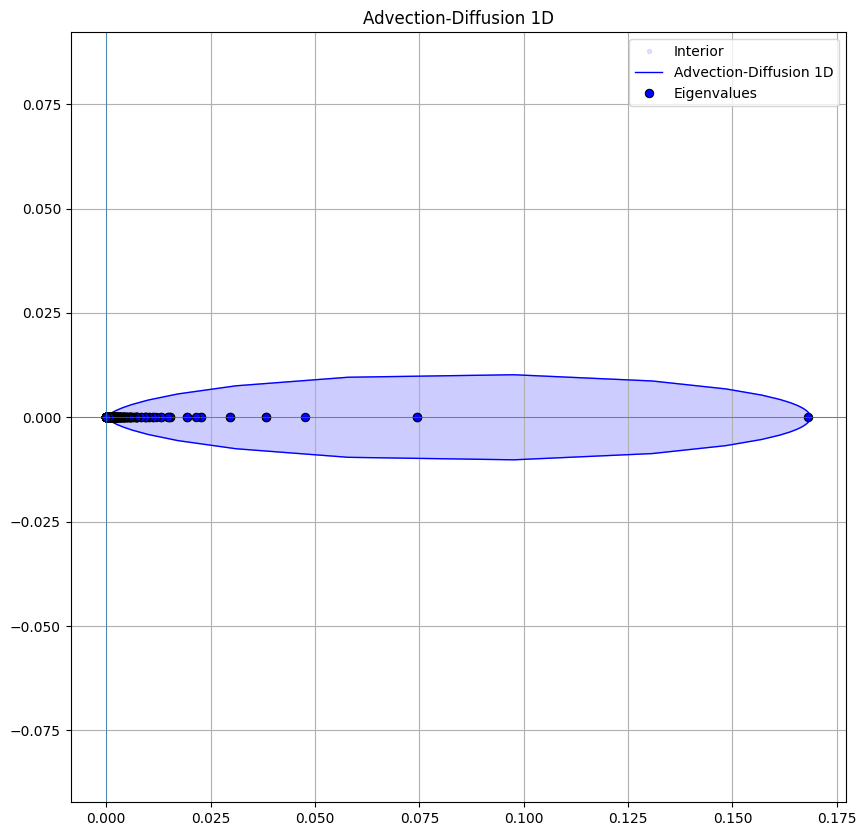

In [787]:

print(A.shape)
plt.figure(figsize=(10, 10))
with TaskManager():
    zm, zM = field_of_values(star, title = "Advection-Diffusion 1D" , fill_in_color = "blue", n_theta = 100)

plt.legend()
plt.axis("equal")


(np.float64(-0.008507123262665686),
 np.float64(0.1771488360338423),
 np.float64(-0.011211600355105409),
 np.float64(0.011211600355105406))

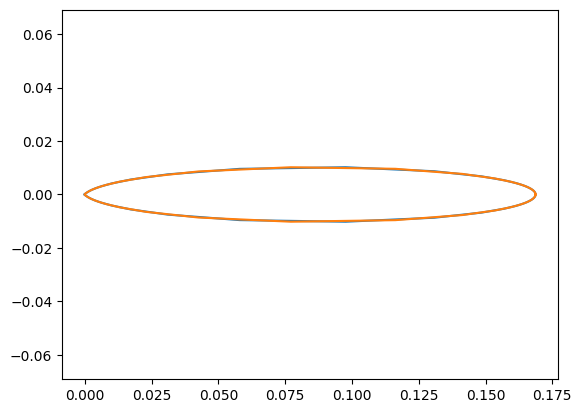

In [788]:
plt.plot(zm.real, zm.imag)
plt.plot(zM.real, zM.imag)
plt.axis("equal")


In [789]:
gfu = GridFunction(fes)
gfu.Set(sin(pi*x)*sin(pi*y))
Draw(gfu)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

BaseWebGuiScene

In [790]:
from scipy.interpolate import PchipInterpolator
Z = zm

# now to ensure that we touch the eigenvalues one can add a small perturbation

# if the points of Z are all in the same spot then we can add a ball perturbation: 

if np.linalg.norm(Z - Z[0]) < 1e-10:
    # Add ball perturbation
    angles = np.linspace(0, 2 * np.pi, len(Z))
    Z = Z + 0.0001 * ( np.exp(1j * angles) )



t = np.linspace(0, 1, len(Z))
sx = PchipInterpolator(t, Z.real)
sy = PchipInterpolator(t, Z.imag)


In [791]:
from scipy.interpolate import PchipInterpolator
Z = zm

# now to ensure that we touch the eigenvalues one can add a small perturbation

# if the points of Z are all in the same spot then we can add a ball perturbation: 

if np.linalg.norm(Z - Z[0]) < 1e-10:
    # Add ball perturbation
    angles = np.linspace(0, 2 * np.pi, len(Z))
    Z = Z + 0.0001 * ( np.exp(1j * angles) )



t = np.linspace(0, 1, len(Z))
sx = PchipInterpolator(t, Z.real)
sy = PchipInterpolator(t, Z.imag)

(np.float64(-0.008507123262665686),
 np.float64(0.1771488360338423),
 np.float64(-0.011211600355105409),
 np.float64(0.011211600355105406))

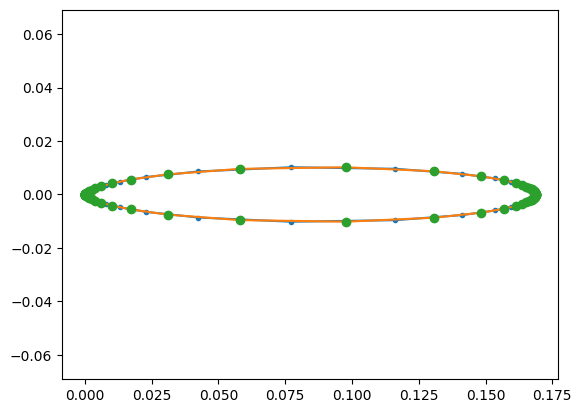

In [792]:
plt.plot(zM.real, zM.imag, '.-')
plt.plot(zm.real, zm.imag, '.-')

plt.plot(sx(t), sy(t), 'o')
plt.axis("equal")


# plot the derivative of the (s(t))


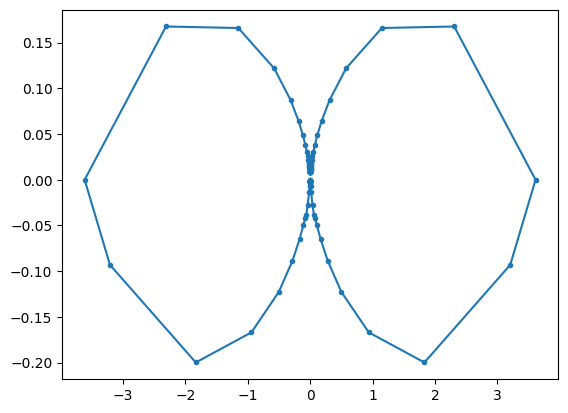

In [793]:
dsx = sx.derivative()
dsy = sy.derivative()

dz_dt = dsx(t) + 1j * dsy(t)

plt.plot(dz_dt.real, dz_dt.imag, '.-')
# now we need to create an object curve that is given by bezier courve that interpolates the points C^1 curve


# To all points the same value:


In [794]:
y = gfu.vec.CreateVector()
y[:]=0
L =len(Z)
for i in range(L):
    z = Z[i]
    z_mid =  1/2*(Z[(i+1)%L] + z)

    dz = Z[(i+1)%L] - z
    dT = 1
    y.data += dT * dz* exp(z_mid) *( z_mid*m.mat - a.mat).CreateSparseMatrix().Inverse(freedofs=fes.FreeDofs()) @ m.mat*gfu.vec 
    
y.data /= (2*pi*1j)

gfu2 = GridFunction(fes)
gfu2.vec.data = y

gfu2 = (gfu2 +Conj(gfu2))/2

Draw(gfu2, mesh)

Draw(exp(1)*gfu -gfu2, mesh)
print(Integrate(Norm(exp(1)*gfu -gfu2)**2, mesh)**0.5)

/var/folders/mw/0_yqnltn6rbg1msz5s15_vgc0000gn/T/ipykernel_72546/3924567240.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  y.data += dT * dz* exp(z_mid) *( z_mid*m.mat - a.mat).CreateSparseMatrix().Inverse(freedofs=fes.FreeDofs()) @ m.mat*gfu.vec


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

2.7175596586006057


In [795]:
0.020456030992740227

0.020456030992740227

# using

In [796]:
y = gfu.vec.CreateVector()
y[:]=0
L =len(Z)
for i in range(L):
    z = sx(t[i]) +1j*sy(t[i])
    dz = dsx(t[i]) -1j*dsy(t[i])
    #dz = -sx.derivative()(t[i]) + 1j * sy.derivative()(t[i])
    #dz = np.sqrt(dz.real**2 + dz.imag**2)
    #dz = sx(t[(i+1)%L]) + 1j*sy(t[(i+1)%L]) - z
    y.data +=  dz* exp(z) *( z*m.mat - a.mat).CreateSparseMatrix().Inverse(freedofs=fes.FreeDofs()) @ m.mat*gfu.vec 
    
y.data /= (2*pi*1j)

gfu2 = GridFunction(fes)
gfu2.vec.data = y

gfu2 = (gfu2 +Conj(gfu2))/2

Draw(gfu2, mesh)

/var/folders/mw/0_yqnltn6rbg1msz5s15_vgc0000gn/T/ipykernel_72546/2990724845.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  y.data +=  dz* exp(z) *( z*m.mat - a.mat).CreateSparseMatrix().Inverse(freedofs=fes.FreeDofs()) @ m.mat*gfu.vec


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

BaseWebGuiScene

In [797]:
Draw(exp(1)*gfu, mesh)


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

BaseWebGuiScene

In [798]:
Draw(exp(1)*gfu +gfu2, mesh)
print(Integrate(Norm(exp(1)*gfu +gfu2)**2, mesh)**0.5)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Complex': {'phase': 0.0, 's…

2.7198117755465985
